# Redesigned Extended Data Figure 1

The former lookup table is rendered as a borderless **AR6 region key**, so the display item contains figures and a figure legend rather than a table.

In [1]:
%load_ext autoreload
%autoreload 2

import sys
import numpy as np
import xarray as xr
import matplotlib as mpl
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import seaborn as sns
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import geopandas as gpd
import regionmask

from shapely.geometry import shape
from mpl_toolkits.axes_grid1.inset_locator import inset_axes

sys.path.append('./functions/')
from obs_function import (
    filter_years_with_valid_quarters,
    notnan_count,
    calculate_regional_nan_years_map,
    plot_ar6_region_data_on_ax,
)

mpl.rcParams.update({
    'font.family': 'sans-serif',
    'font.sans-serif': ['Arial', 'Helvetica', 'DejaVu Sans'],
    'pdf.fonttype': 42,
    'svg.fonttype': 'none',
})

In [2]:
# Reproduce the observational-coverage calculation used in 0.0_HadCRUT5.ipynb.
input_path = './input_file/'
input_name = 'HadCRUT.5.0.2.0.non-infilled.anomalies.ensemble_mean.nc'

dataset = xr.open_dataset(input_path + input_name)
tas_had_nan = dataset['tas_mean'].rename({'latitude': 'lat', 'longitude': 'lon'})
tas_had_reshaped_nan = tas_had_nan.groupby('time.year').apply(
    lambda values: values.groupby('time.month').mean()
)
tas_had_yr_mon_nan = tas_had_reshaped_nan.transpose('year', 'month', 'lat', 'lon')
tas_had_yr_75per = filter_years_with_valid_quarters(
    tas_had_yr_mon_nan, min_valid_quarters=3
)

(
    tas_nan_yr_AR6_had,
    tas_regional_nonmask_AR6_had,
    grid_per_region_AR6_had,
    tas_regional_mask_AR6_had,
) = calculate_regional_nan_years_map(tas_grid=tas_had_yr_75per, threshold=0.75)

In [3]:
# Borderless figure key, grouped by continent (not a table).
region_key = {
    'North and Central America': [
        ('GIC', 'Greenland/Iceland'), ('NWN', 'N.W. North-America'),
        ('NEN', 'N.E. North-America'), ('WNA', 'W. North-America'),
        ('CNA', 'C. North-America'), ('ENA', 'E. North-America'),
        ('NCA', 'N. Central-America'), ('SCA', 'S. Central-America'),
        ('CAR', 'Caribbean'),
    ],
    'South America': [
        ('NWS', 'N.W. South-America'), ('NSA', 'N. South-America'),
        ('NES', 'N.E. South-America'), ('SAM', 'South-America–monsoon'),
        ('SWS', 'S.W. South-America'), ('SES', 'S.E. South-America'),
        ('SSA', 'S. South-America'),
    ],
    'Europe': [
        ('NEU', 'N. Europe'), ('WCE', 'Western & Central-Europe'),
        ('EEU', 'E. Europe'), ('MED', 'Mediterranean'),
    ],
    'Africa': [
        ('SAH', 'Sahara'), ('WAF', 'Western-Africa'), ('CAF', 'Central-Africa'),
        ('NEAF', 'N. Eastern-Africa'), ('SEAF', 'S. Eastern-Africa'),
        ('WSAF', 'W. Southern-Africa'), ('ESAF', 'E. Southern-Africa'),
        ('MDG', 'Madagascar'),
    ],
    'Asia': [
        ('RAR', 'Russian-Arctic'), ('WSB', 'W. Siberia'), ('ESB', 'E. Siberia'),
        ('RFE', 'Russian–Far–East'), ('WCA', 'W. C. Asia'), ('ECA', 'E. C. Asia'),
        ('TIB', 'Tibetan–Plateau'), ('EAS', 'E. Asia'),
        ('ARP', 'Arabian–Peninsula'), ('SAS', 'S. Asia'), ('SEA', 'S. E. Asia'),
    ],
    'Australasia': [
        ('NAU', 'N. Australia'), ('CAU', 'C. Australia'), ('EAU', 'E. Australia'),
        ('SAU', 'S. Australia'), ('NZ', 'New–Zealand'),
    ],
    'Antarctica': [('EAN', 'E. Antarctica'), ('WAN', 'W. Antarctica')],
}

key_columns = [
    ['North and Central America', 'Antarctica'],
    ['South America', 'Europe'],
    ['Africa', 'Australasia'],
    ['Asia'],
]

In [ ]:

# Source Data export (Nature Portfolio): one machine-readable CSV for this display item.
from pathlib import Path as _SDPath
import csv as _sdcsv
import numpy as _sdnp

_sd_dir = _SDPath('./Source Data')
_sd_dir.mkdir(parents=True, exist_ok=True)

def _sd_scalar(value):
    return float(_sdnp.asarray(value).squeeze())

def _sd_text(value):
    return str(_sdnp.asarray(value).item())

def _sd_write(filename, rows, fieldnames):
    path = _sd_dir / filename
    with path.open('w', newline='', encoding='utf-8') as handle:
        writer = _sdcsv.DictWriter(handle, fieldnames=fieldnames, extrasaction='ignore')
        writer.writeheader()
        writer.writerows(rows)
    print(f'Wrote {path} ({len(rows):,} data rows)')

_group_by_abbrev = {str(item[0]):g for g, entries in region_key.items() for item in entries}
_rows = []
for i in range(tas_nan_yr_AR6_had.sizes['region']):
    _abbr = str(tas_nan_yr_AR6_had.abbrevs.values[i])
    _rows.append({'panels':'a,b', 'region_index':int(tas_nan_yr_AR6_had.region.values[i]),
                  'region_abbreviation':_abbr,
                  'region_name':str(tas_nan_yr_AR6_had.names.values[i]),
                  'continent':_group_by_abbrev.get(_abbr,''),
                  'years_without_sufficient_observations':_sd_scalar(tas_nan_yr_AR6_had.isel(region=i)),
                  'boundary_source':'AR6 land reference regions (Iturbide et al., 2020, ESSD)'})
_sd_write('Source_Data_ED_Fig1.csv', _rows,
          ['panels','region_index','region_abbreviation','region_name','continent',
           'years_without_sufficient_observations','boundary_source'])


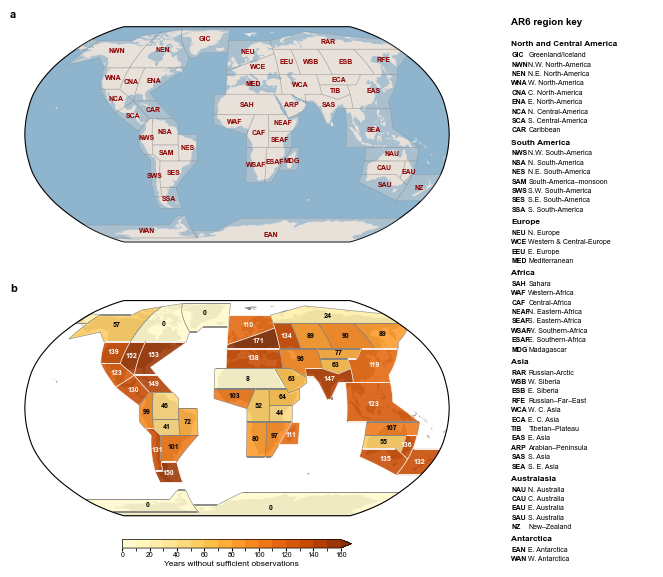

In [25]:
# Plot the two maps and the borderless AR6 region key.
FIG_WIDTH_MM, FIG_HEIGHT_MM = 180, 160
fig = plt.figure(figsize=(FIG_WIDTH_MM / 25.4, FIG_HEIGHT_MM / 25.4))
gs = fig.add_gridspec(
    2, 2, width_ratios=[2.15, 1.0], height_ratios=[1.0, 1.0],
    left=0.025, right=0.99, top=0.975, bottom=0.145,
    wspace=0.2, hspace=0.1,
)

projection = ccrs.Robinson()
ar6_regions = regionmask.defined_regions.ar6.land
ar6_gdf = gpd.GeoDataFrame(
    {
        'region': ar6_regions.abbrevs,
        'geometry': [shape(polygon) for polygon in ar6_regions.polygons],
    },
    crs='EPSG:4326',
)

# a, AR6 reference regions.
ax_a = fig.add_subplot(gs[0, 0], projection=projection)
ax_a.set_global()
ax_a.add_feature(cfeature.LAND, facecolor='#f5ebe0', linewidth=0)
ax_a.add_feature(cfeature.OCEAN, facecolor='#6096ba', alpha=0.7, linewidth=0)
ar6_gdf.to_crs(projection.proj4_init).plot(
    ax=ax_a, edgecolor='gray', facecolor='lightgray',
    linewidth=0.45, zorder=3, alpha=0.4,
)
for index, abbreviation in enumerate(ar6_regions.abbrevs):
    lon, lat = ar6_regions.centroids[index]
    ax_a.text(
        lon, lat, abbreviation, transform=ccrs.PlateCarree(),
        ha='center', va='center', fontsize=5.0,
        color='darkred', weight='bold',
    )
ax_a.text(-0.035, 1.03, 'a', transform=ax_a.transAxes,
          fontsize=8.0, fontweight='bold', ha='left', va='bottom')

# b, number of years without sufficient observations.
ax_b = fig.add_subplot(gs[1, 0], projection=projection)
ax_b.set_global()
cmap = sns.color_palette('YlOrBr', as_cmap=True)
colors_array = cmap(np.linspace(0, 1, 256))[20:236]
truncated_cmap = mcolors.LinearSegmentedColormap.from_list(
    'truncated_YlOrBr', colors_array
)
bounds = np.arange(0, 170, 10)
norm = mcolors.BoundaryNorm(boundaries=bounds, ncolors=256, extend='max')
plot_ar6_region_data_on_ax(
    ax_b, tas_nan_yr_AR6_had, cmap=truncated_cmap, norm=norm,
    decimals=0, linewidth=0.45, label_fontsize=5.0,
    region_shifts={'SWS': (2.0, 0), 'EAU': (-2.0, 0)},
)
ax_b.text(-0.035, 1.03, 'b', transform=ax_b.transAxes,
          fontsize=8.0, fontweight='bold', ha='left', va='bottom')

cax = inset_axes(
    ax_b, width='54%', height='4%', loc='lower center',
    bbox_to_anchor=(0, -0.15, 1, 1), bbox_transform=ax_b.transAxes,
    borderpad=0,
)
sm = mpl.cm.ScalarMappable(cmap=truncated_cmap, norm=norm)
sm.set_array([])
colorbar = fig.colorbar(sm, cax=cax, orientation='horizontal')
colorbar.ax.tick_params(labelsize=5.0, length=2, pad=1)
colorbar.set_label('Years without sufficient observations', fontsize=6.0, labelpad=2)
colorbar.outline.set_linewidth(0.5)

# AR6 region key
ax_key = fig.add_subplot(gs[:, 1])
ax_key.set_axis_off()
# Shorten only the invisible key axis so tight PDF export removes excess right margin.
key_position = ax_key.get_position()
ax_key.set_position([
    key_position.x0, key_position.y0,
    key_position.width * 0.72, key_position.height,
])
ax_key.text(0.0, 0.985, 'AR6 region key', transform=ax_key.transAxes,
            fontsize=7.0, fontweight='bold', ha='left', va='top')

line_step = 0.018
y_position = 0.94
for continent, entries in region_key.items():
    ax_key.text(
        0.0, y_position, continent, transform=ax_key.transAxes,
        fontsize=6.0, fontweight='bold', ha='left', va='top',
    )
    y_position -= line_step * 1.15
    for abbreviation, region_name in entries:
        ax_key.text(
            0.0, y_position, abbreviation,
            transform=ax_key.transAxes, fontsize=5.0, fontweight='bold',
            ha='left', va='top',
        )
        ax_key.text(
            0.12, y_position, region_name,
            transform=ax_key.transAxes, fontsize=5.0,
            ha='left', va='top',
        )
        y_position -= line_step
    y_position -= line_step * 0.28

plt.show()
fig.savefig(
    './saved_figures/ED_Fig1.pdf',
    format='pdf', bbox_inches='tight', pad_inches=0.02,
    metadata={'Title': 'Extended Data Figure 1'},
)